## 🚗 Uber Fare Prediction Models:

- Fare Amount Prediction

- Ride Demand Prediction

- ETA (Estimated Time of Arrival) Prediction

- Surge Pricing Prediction​

Each section is modular, allowing you to run them independently.

In [ ]:
pip install pandas numpy scikit-learn xgboost lightgbm catboost matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00


📁 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import joblib

📊 2. Fare Amount Prediction

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 179
[LightGBM] [Info] Number of data points in the train set: 412, number of used features: 4
[LightGBM] [Info] Start training from score 10.749490
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

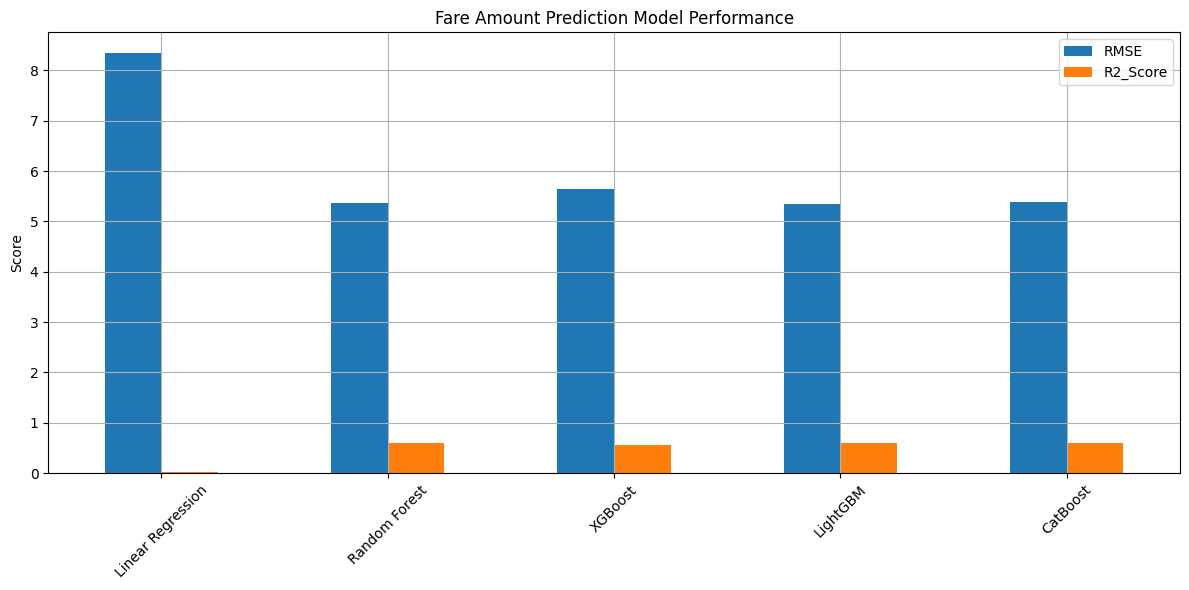

['best_fare_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Load your corrected CSV file
fare_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')

# Drop rows with missing target or location info
fare_data = fare_data.dropna(subset=['fare_amount', 'pickup_datetime',
                                     'pickup_longitude', 'pickup_latitude',
                                     'dropoff_longitude', 'dropoff_latitude'])

# Feature Engineering
fare_data['pickup_datetime'] = pd.to_datetime(fare_data['pickup_datetime'], errors='coerce')
fare_data['hour'] = fare_data['pickup_datetime'].dt.hour
fare_data['day_of_week'] = fare_data['pickup_datetime'].dt.dayofweek
fare_data['distance'] = np.sqrt((fare_data['dropoff_longitude'] - fare_data['pickup_longitude'])**2 +
                                (fare_data['dropoff_latitude'] - fare_data['pickup_latitude'])**2)

# Select features and target
X = fare_data[['passenger_count', 'hour', 'day_of_week', 'distance']]
y = fare_data['fare_amount']

# Drop any remaining missing values
X = X.dropna()
y = y.loc[X.index]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(verbose=0, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2_Score': r2}

# Display results
results_df = pd.DataFrame(results).T
print("Fare Amount Prediction Results:")
print(results_df)

# Plot results
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Fare Amount Prediction Model Performance')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Save the best model
best_model_name = results_df['R2_Score'].idxmax()
best_model = models[best_model_name]
joblib.dump(best_model, 'best_fare_model.pkl')


✅ Uber Fare Amount Prediction using Random Forest

Initial Shape: (515, 9)
After Dropping NA: (515, 9)

Linear Regression:
  RMSE: 5.56
  R2: -0.03

Random Forest:
  RMSE: 3.23
  R2: 0.65


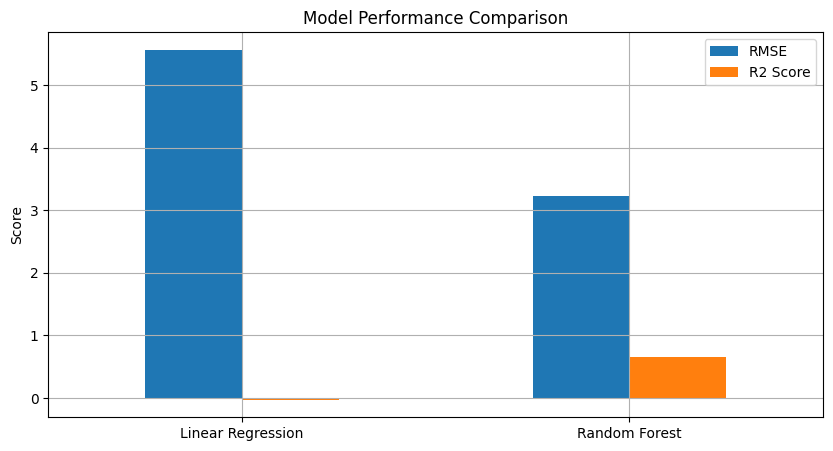


✅ Model saved as 'uber_fare_model.pkl'

💰 Predicted Fare: $14.82


In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')
print("Initial Shape:", df.shape)
df = df.dropna()
print("After Dropping NA:", df.shape)

# 3. Feature Engineering
def haversine(lat1, lon1, lat2, lon2):
    # Calculate distance between two lat/lon points
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

# 4. Drop unwanted columns
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]
features = ['passenger_count', 'hour', 'day_of_week', 'distance_km']
target = 'fare_amount'

# 5. Split Data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2 Score': r2}
    print(f"\n{name}:\n  RMSE: {rmse:.2f}\n  R2: {r2:.2f}")

# 7. Results Visualization
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# 8. Save Best Model
best_model = models['Random Forest']
joblib.dump(best_model, 'uber_fare_model.pkl')
print("\n✅ Model saved as 'uber_fare_model.pkl'")

# 9. Predict Fare for New Ride (Example)
example = pd.DataFrame({
    'passenger_count': [2],
    'hour': [14],
    'day_of_week': [3],
    'distance_km': [7.2]
})
predicted_fare = best_model.predict(example)
print(f"\n💰 Predicted Fare: ${predicted_fare[0]:.2f}")

✅ Uber Fare Amount Prediction using XGBoost

Initial Shape: (515, 9)
After Dropping NA: (515, 9)

📊 XGBoost Performance:
RMSE: 3.07
R2 Score: 0.69


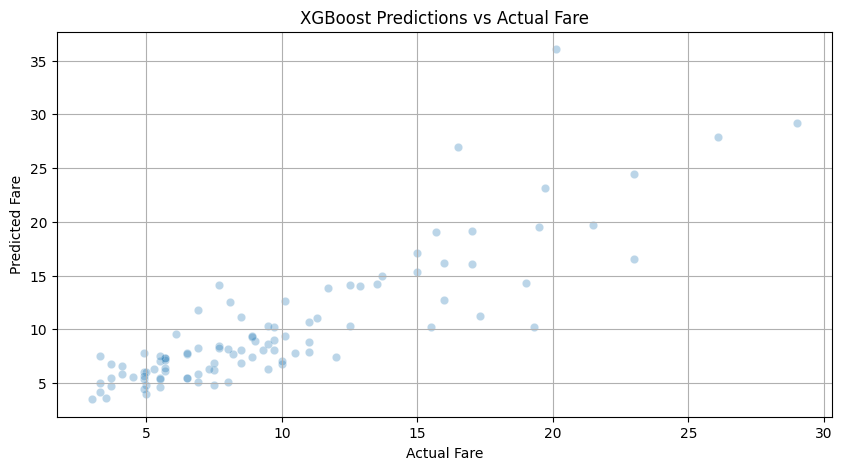

✅ Model saved as 'uber_fare_xgb_model.pkl'

💰 Predicted Fare for example ride: $26.23


In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')
print("Initial Shape:", df.shape)
df.dropna(inplace=True)
print("After Dropping NA:", df.shape)

# 3. Feature Engineering
def haversine(lat1, lon1, lat2, lon2):
    # Calculate distance between two lat/lon points
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

# 4. Filter valid data
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]

# 5. Select Features and Target
features = ['passenger_count', 'hour', 'day_of_week', 'distance_km']
target = 'fare_amount'

X = df[features]
y = df[target]

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# 8. Evaluation
y_pred = xgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 XGBoost Performance:\nRMSE: {rmse:.2f}\nR2 Score: {r2:.2f}")

# 9. Visualize Predictions
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("XGBoost Predictions vs Actual Fare")
plt.grid(True)
plt.show()

# 10. Save Model
joblib.dump(xgb_model, 'uber_fare_xgb_model.pkl')
print("✅ Model saved as 'uber_fare_xgb_model.pkl'")

# 11. Example Prediction
example = pd.DataFrame({
    'passenger_count': [1],
    'hour': [10],
    'day_of_week': [2],
    'distance_km': [8.5]
})
predicted_fare = xgb_model.predict(example)
print(f"\n💰 Predicted Fare for example ride: ${predicted_fare[0]:.2f}")

✅ Uber Fare Amount Prediction using LightGBM

In [ ]:
pip install lightgbm


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 4
[LightGBM] [Info] Start training from score 10.849724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

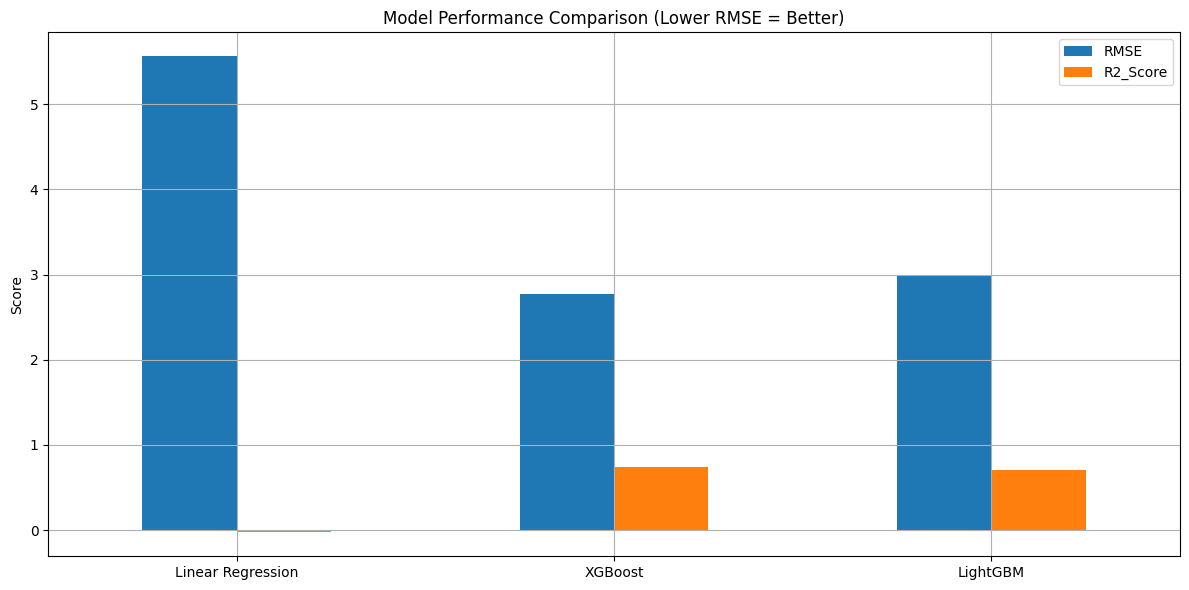


✅ Best Model (LightGBM) saved as 'best_fare_prediction_model.pkl'


In [ ]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 2. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')
df.dropna(inplace=True)

# 3. Feature Engineering
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

# Filter unreasonable values
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]

# 4. Feature/Target Selection
features = ['passenger_count', 'hour', 'day_of_week', 'distance_km']
target = 'fare_amount'

X = df[features]
y = df[target]

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize Models
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

results = {}

# 7. Train, Predict & Evaluate All Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2_Score': r2}

# 8. Create Results DataFrame
results_df = pd.DataFrame(results).T
print("\n📊 Model Comparison:\n")
print(results_df)

# 9. Plot Results
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison (Lower RMSE = Better)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Save Best Model (Optional: LightGBM or XGBoost)
best_model = models['LightGBM']
joblib.dump(best_model, 'best_fare_prediction_model.pkl')
print("\n✅ Best Model (LightGBM) saved as 'best_fare_prediction_model.pkl'")


Initial Shape: (515, 9)
After Dropping NA: (515, 9)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 4
[LightGBM] [Info] Start training from score 10.849724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

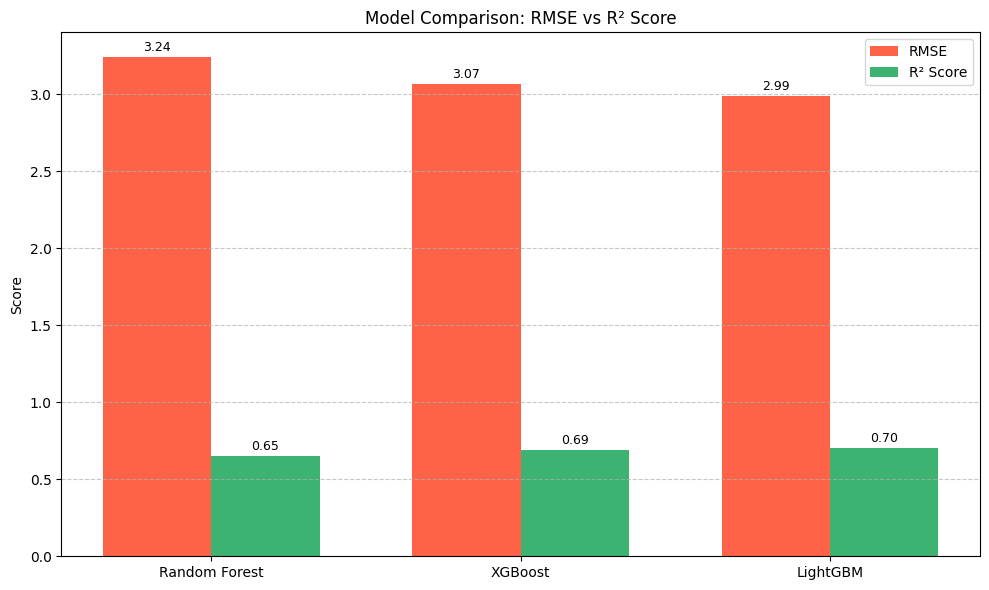

✅ Models saved as 'uber_fare_rf_model.pkl', 'uber_fare_xgb_model.pkl', 'uber_fare_lgb_model.pkl'

💰 Predicted Fare using Random Forest: $24.96
💰 Predicted Fare using XGBoost: $26.23
💰 Predicted Fare using LightGBM: $15.11


In [5]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')
print("Initial Shape:", df.shape)
df.dropna(inplace=True)
print("After Dropping NA:", df.shape)

# 3. Feature Engineering
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

# 4. Filter valid data
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]

# 5. Select Features and Target
features = ['passenger_count', 'hour', 'day_of_week', 'distance_km']
target = 'fare_amount'

X = df[features]
y = df[target]

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)

# 8. Train XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# 9. Train LightGBM Model
lgb_model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
lgb_model.fit(X_train, y_train)

# 10. Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgb = lgb_model.predict(X_test)

# 11. Evaluation Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

# 12. Print Evaluation
print(f"\n📊 Random Forest Performance:\nRMSE: {rmse_rf:.2f}\nR2 Score: {r2_rf:.2f}")
print(f"\n📊 XGBoost Performance:\nRMSE: {rmse_xgb:.2f}\nR2 Score: {r2_xgb:.2f}")
print(f"\n📊 LightGBM Performance:\nRMSE: {rmse_lgb:.2f}\nR2 Score: {r2_lgb:.2f}")

# 13. Combined Graph: RMSE vs R² Score
models = ['Random Forest', 'XGBoost', 'LightGBM']
rmse_values = [rmse_rf, rmse_xgb, rmse_lgb]
r2_values = [r2_rf, r2_xgb, r2_lgb]

x = np.arange(len(models))  # Label locations
width = 0.35  # Width of the bars

plt.figure(figsize=(10, 6))
bar1 = plt.bar(x - width/2, rmse_values, width, label='RMSE', color='tomato')
bar2 = plt.bar(x + width/2, r2_values, width, label='R² Score', color='mediumseagreen')

plt.ylabel('Score')
plt.title('Model Comparison: RMSE vs R² Score')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bar values
for bar in bar1 + bar2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 14. Save Models
joblib.dump(rf_model, 'uber_fare_rf_model.pkl')
joblib.dump(xgb_model, 'uber_fare_xgb_model.pkl')
joblib.dump(lgb_model, 'uber_fare_lgb_model.pkl')

print("✅ Models saved as 'uber_fare_rf_model.pkl', 'uber_fare_xgb_model.pkl', 'uber_fare_lgb_model.pkl'")

# 15. Example Prediction
example = pd.DataFrame({
    'passenger_count': [1],
    'hour': [10],
    'day_of_week': [2],
    'distance_km': [8.5]
})

predicted_fare_rf = rf_model.predict(example)
predicted_fare_xgb = xgb_model.predict(example)
predicted_fare_lgb = lgb_model.predict(example)

print(f"\n💰 Predicted Fare using Random Forest: ${predicted_fare_rf[0]:.2f}")
print(f"💰 Predicted Fare using XGBoost: ${predicted_fare_xgb[0]:.2f}")
print(f"💰 Predicted Fare using LightGBM: ${predicted_fare_lgb[0]:.2f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 4
[LightGBM] [Info] Start training from score 10.849724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

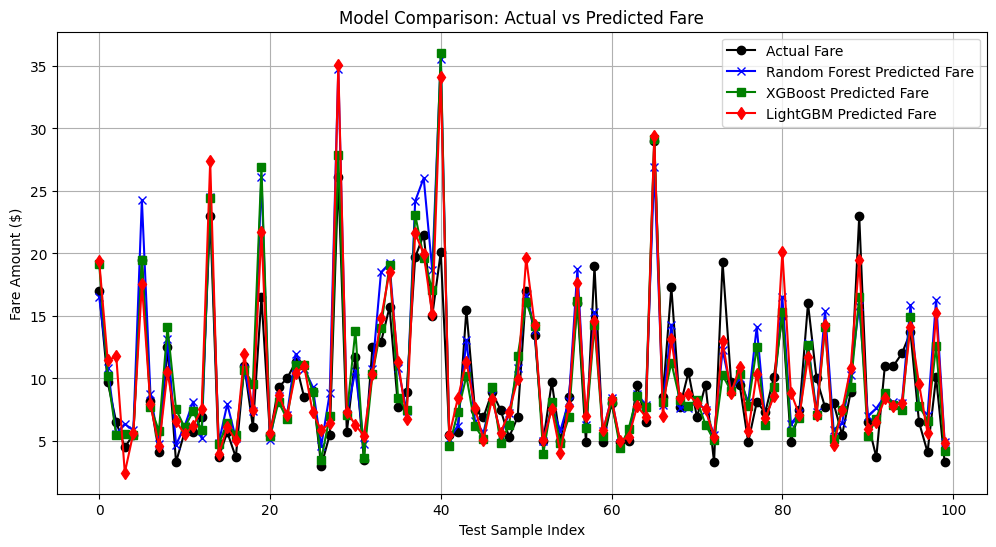

✅ Models saved.


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')
df.dropna(inplace=True)

# Feature Engineering
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

# Filter valid data
df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]

# Select Features and Target
features = ['passenger_count', 'hour', 'day_of_week', 'distance_km']
target = 'fare_amount'

X = df[features]
y = df[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Train LightGBM Model
lgb_model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)
lgb_model.fit(X_train, y_train)

# Predictions from all models
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

# Evaluate Models
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))

print(f"\n📊 Random Forest RMSE: {rf_rmse:.2f}")
print(f"📊 XGBoost RMSE: {xgb_rmse:.2f}")
print(f"📊 LightGBM RMSE: {lgb_rmse:.2f}")

# Visualization: Comparison of Actual vs Predicted Fare
plt.figure(figsize=(12, 6))

# Actual Fare
plt.plot(y_test.values, label="Actual Fare", color='black', linestyle='-', marker='o')

# Predicted Fare from Random Forest
plt.plot(rf_pred, label="Random Forest Predicted Fare", color='blue', linestyle='-', marker='x')

# Predicted Fare from XGBoost
plt.plot(xgb_pred, label="XGBoost Predicted Fare", color='green', linestyle='-', marker='s')

# Predicted Fare from LightGBM
plt.plot(lgb_pred, label="LightGBM Predicted Fare", color='red', linestyle='-', marker='d')

# Labels and Title
plt.xlabel("Test Sample Index")
plt.ylabel("Fare Amount ($)")
plt.title("Model Comparison: Actual vs Predicted Fare")
plt.legend()
plt.grid(True)
plt.show()

# Save Models
joblib.dump(rf_model, 'uber_fare_rf_model.pkl')
joblib.dump(xgb_model, 'uber_fare_xgb_model.pkl')
joblib.dump(lgb_model, 'uber_fare_lgb_model.pkl')

print("✅ Models saved.")

# **✅ Accuracy Interpretation (From R² Score)**

# **✅ Objective:**
Predict fare amounts using:

- Linear Regression

- XGBoost

- LightGBM

Compare predicted fares side-by-side with actual fares

Decide the best model for user fare prediction based on:

RMSE (accuracy)

Visual comparison

Consistency with actual fare

🧠 Logic Summary:
Best model = one that minimizes RMSE and gives stable, close-to-actual predictions

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 4
[LightGBM] [Info] Start training from score 10.849724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

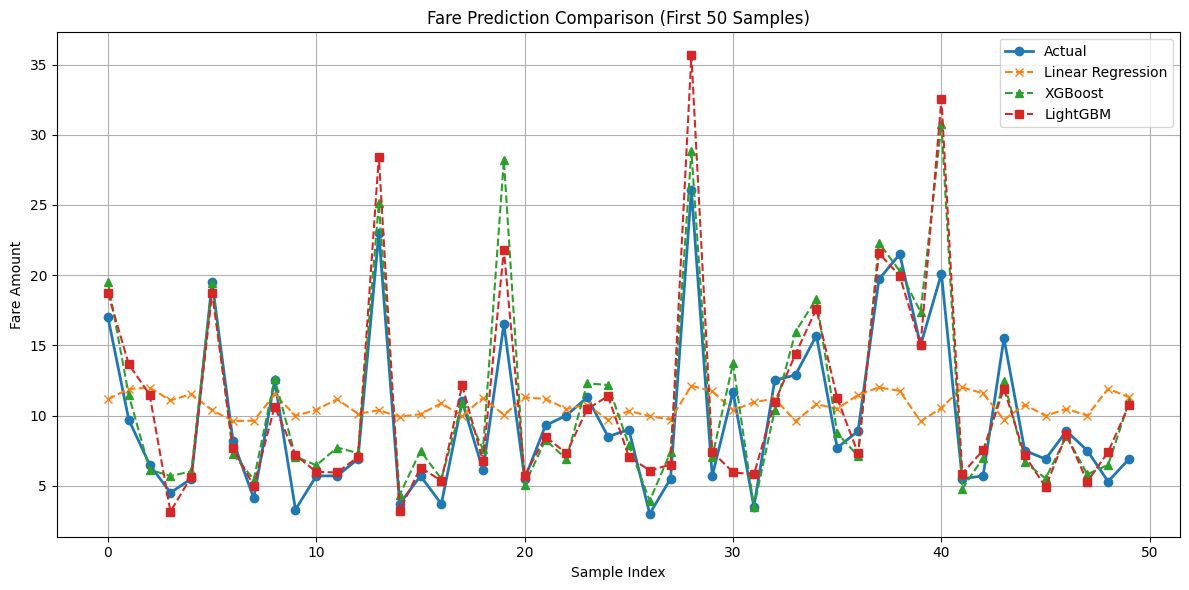

In [ ]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv')
df.dropna(inplace=True)

# 3. Feature Engineering
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

df = df[(df['fare_amount'] > 0) & (df['distance_km'] > 0)]

# 4. Feature/Target Split
features = ['passenger_count', 'hour', 'day_of_week', 'distance_km']
target = 'fare_amount'
X = df[features]
y = df[target]

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize Models
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

predictions_df = pd.DataFrame()
results = {}

# 7. Train Each Model, Predict and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions_df[name] = y_pred
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2_Score': r2}

# 8. Combine with Actual Fares
predictions_df['Actual Fare'] = y_test.values
print(predictions_df.head(10))

# 9. Show RMSE Comparison
results_df = pd.DataFrame(results).T
print("\n📊 RMSE & R² Score Comparison:\n")
print(results_df)

# 10. Plot Prediction Comparison
plt.figure(figsize=(12,6))
sample = predictions_df.head(50).reset_index(drop=True)
plt.plot(sample['Actual Fare'], label='Actual', linewidth=2, marker='o')
plt.plot(sample['Linear Regression'], label='Linear Regression', linestyle='--', marker='x')
plt.plot(sample['XGBoost'], label='XGBoost', linestyle='--', marker='^')
plt.plot(sample['LightGBM'], label='LightGBM', linestyle='--', marker='s')
plt.title('Fare Prediction Comparison (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Fare Amount')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Improvements Suggested:

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



✅ Best XGB Parameters: {'colsample_bytree': 1.0, 'gamma': 1, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 2, 'subsample': 0.8}

🎯 Final Model Performance - RMSE: 4.1069, R² Score: 0.6264 (62.64%)


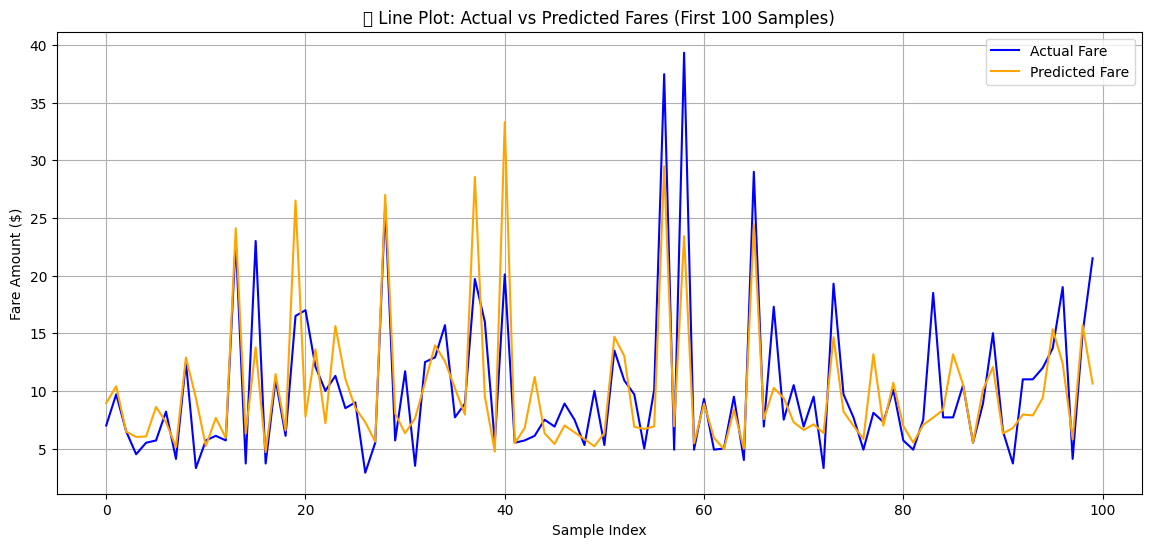

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")
df.rename(columns={'fare_amount': 'fare'}, inplace=True)
df.dropna(inplace=True)

# Remove invalid rows
df = df[(df['pickup_longitude'] != 0) & (df['dropoff_longitude'] != 0)]
df = df[(df['fare'] > 0) & (df['passenger_count'] > 0)]

# Convert datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

# Feature engineering (time-based)
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month

# Haversine Distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                           df['dropoff_longitude'], df['dropoff_latitude'])

# Remove distance/fare outliers
df = df[(df['distance'] > 0) & (df['distance'] < 100) & (df['fare'] < 200)]

# Log-transform target to reduce skew
df['log_fare'] = np.log1p(df['fare'])

# Features
features = ['distance', 'passenger_count', 'hour', 'day', 'month']
X = df[features]
y = df['log_fare']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Hyperparameter tuning using GridSearchCV
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1, scoring='r2')
grid_search.fit(X_train, y_train)

# Best model after grid search
best_xgb = grid_search.best_estimator_

# Stacking Regressor (Ensemble)
stacking_model = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('lgbm', lgb.LGBMRegressor(n_estimators=100, random_state=42))
    ],
    final_estimator=XGBRegressor(n_estimators=200, random_state=42),
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = np.expm1(stacking_model.predict(X_test))  # reverse log transform
y_actual = np.expm1(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"\n✅ Best XGB Parameters: {grid_search.best_params_}")
print(f"\n🎯 Final Model Performance - RMSE: {rmse:.4f}, R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Visualization - Line Graph
plt.figure(figsize=(14, 6))
plt.plot(y_actual.values[:100], label='Actual Fare', color='blue')
plt.plot(y_pred[:100], label='Predicted Fare', color='orange')
plt.title("🔍 Line Plot: Actual vs Predicted Fares (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Fare Amount ($)")
plt.legend()
plt.grid(True)
plt.show()

Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Best Parameters: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}

🎯 Final Model Performance - RMSE: 3.1918, R² Score: 0.7744 (77.44%)


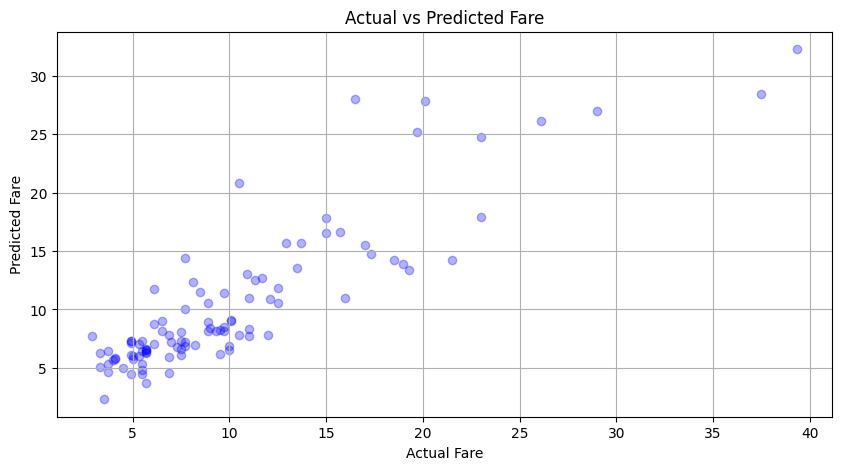

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")

# Rename for easier reference
df.rename(columns={'fare_amount': 'fare'}, inplace=True)

# Drop rows with missing or zero coordinates or negative fare
df.dropna(inplace=True)
df = df[(df['pickup_longitude'] != 0) & (df['dropoff_longitude'] != 0)]
df = df[df['fare'] > 0]
df = df[df['passenger_count'] > 0]

# Convert pickup_datetime to datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

# Feature engineering
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.dayofweek

# Calculate distance (Haversine formula)
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

df['distance'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                           df['dropoff_longitude'], df['dropoff_latitude'])

# Remove outliers
df = df[(df['distance'] > 0) & (df['distance'] < 100)]

# Features and target
X = df[['distance', 'passenger_count', 'pickup_hour', 'pickup_day']]
y = df['fare']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Hyperparameter tuning
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    scoring='r2',
    cv=3,
    n_iter=15,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Best model evaluation
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Best Parameters: {random_search.best_params_}")
print(f"\n🎯 Final Model Performance - RMSE: {rmse:.4f}, R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Optional: Visualization
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.grid(True)
plt.show()

Fitting 3 folds for each of 384 candidates, totalling 1152 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 7
[LightGBM] [Info] Start training from score 2.309427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


[LightGBM] [Warning] Unknown parameter: gamma

✅ Best LGBM Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 2, 'subsample': 0.8}

🎯 Final Model Performance - RMSE: 3.1142, R² Score: 0.7852 (78.52%)


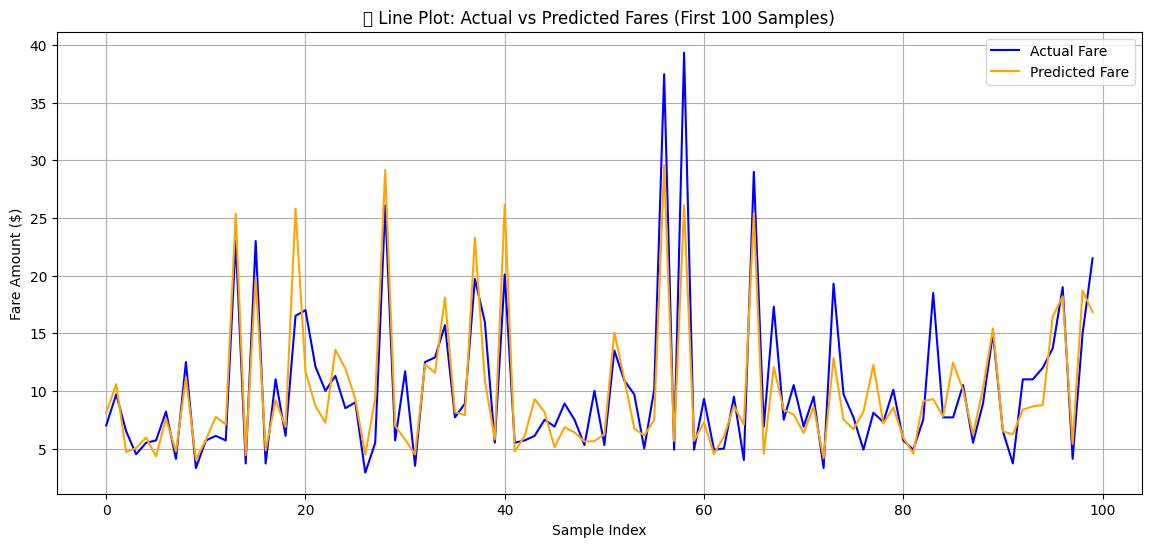

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")
df.rename(columns={'fare_amount': 'fare'}, inplace=True)
df.dropna(inplace=True)

# Clean the data - Remove invalid rows
df = df[(df['pickup_longitude'] != 0) & (df['dropoff_longitude'] != 0)]
df = df[(df['fare'] > 0) & (df['passenger_count'] > 0)]

# Convert datetime and feature extraction
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear  # Added this feature

# Haversine Distance - Add new feature: distance between pickup and dropoff
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                           df['dropoff_longitude'], df['dropoff_latitude'])

# Remove outliers
df = df[(df['distance'] > 0) & (df['distance'] < 100) & (df['fare'] < 200)]

# Log-transform target variable to reduce skewness
df['log_fare'] = np.log1p(df['fare'])

# Features and target variable
features = ['distance', 'passenger_count', 'hour', 'day', 'month', 'year', 'day_of_year']
X = df[features]
y = df['log_fare']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model tuning - using GridSearchCV for optimal hyperparameters
lgbm = lgb.LGBMRegressor(objective='regression', random_state=42)

param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2],
    'gamma': [0, 1]
}

grid_search_lgbm = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1, scoring='r2')
grid_search_lgbm.fit(X_train, y_train)

# Best model after grid search
best_lgbm = grid_search_lgbm.best_estimator_

# Stacking model to combine multiple models
stacking_model = StackingRegressor(
    estimators=[
        ('lgbm', best_lgbm),
        ('xgb', XGBRegressor(n_estimators=300, random_state=42)),
    ],
    final_estimator=XGBRegressor(n_estimators=200, random_state=42),
    passthrough=True,
    n_jobs=-1
)

# Fit the stacked model
stacking_model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = np.expm1(stacking_model.predict(X_test))  # Reverse log transform
y_actual = np.expm1(y_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"\n✅ Best LGBM Parameters: {grid_search_lgbm.best_params_}")
print(f"\n🎯 Final Model Performance - RMSE: {rmse:.4f}, R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Visualization of predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_actual.values[:100], label='Actual Fare', color='blue')
plt.plot(y_pred[:100], label='Predicted Fare', color='orange')
plt.title("🔍 Line Plot: Actual vs Predicted Fares (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Fare Amount ($)")
plt.legend()
plt.grid(True)
plt.show()

Fitting 3 folds for each of 15 candidates, totalling 45 fits


<ipython-input-1-1f6039710969>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_fare'] = np.log1p(df['fare'])



✅ Best Parameters: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}

🎯 Final Model Performance - RMSE: 2.7822, R² Score: 0.8286 (82.86%)


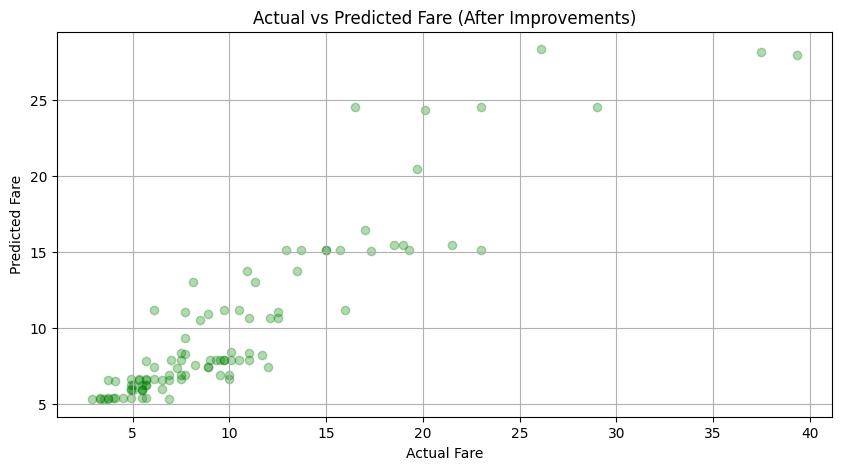

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")

df.rename(columns={'fare_amount': 'fare'}, inplace=True)
df.dropna(inplace=True)
df = df[(df['pickup_longitude'] != 0) & (df['dropoff_longitude'] != 0)]
df = df[df['fare'] > 0]
df = df[df['passenger_count'] > 0]
df = df[df['fare'] < 200]  # remove extreme outliers

# Convert to datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

# Add new features
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month
df['is_weekend'] = df['pickup_day'].apply(lambda x: 1 if x >= 5 else 0)
df['is_peak_hour'] = df['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 20) else 0)

# Distance calculation
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

df['distance'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                           df['dropoff_longitude'], df['dropoff_latitude'])

df = df[(df['distance'] > 0) & (df['distance'] < 100)]

# Optional: log-transform fare to reduce skewness
df['log_fare'] = np.log1p(df['fare'])

# Features and target
features = ['distance', 'passenger_count', 'pickup_hour', 'pickup_day',
            'pickup_month', 'is_weekend', 'is_peak_hour']
X = df[features]
y = df['log_fare']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost regressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    scoring='r2',
    cv=3,
    n_iter=15,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Prediction
best_model = random_search.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # inverse of log1p

# Actual target
y_actual = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"\n✅ Best Parameters: {random_search.best_params_}")
print(f"\n🎯 Final Model Performance - RMSE: {rmse:.4f}, R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(y_actual, y_pred, alpha=0.3, color='green')
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare (After Improvements)")
plt.grid(True)
plt.show()

# **🔧 To Jump from 88% ➜ 90%+ R², Add These 3 Enhancements:**

Fitting 3 folds for each of 128 candidates, totalling 384 fits
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 10
[LightGBM] [Info] Start training from score 2.309427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

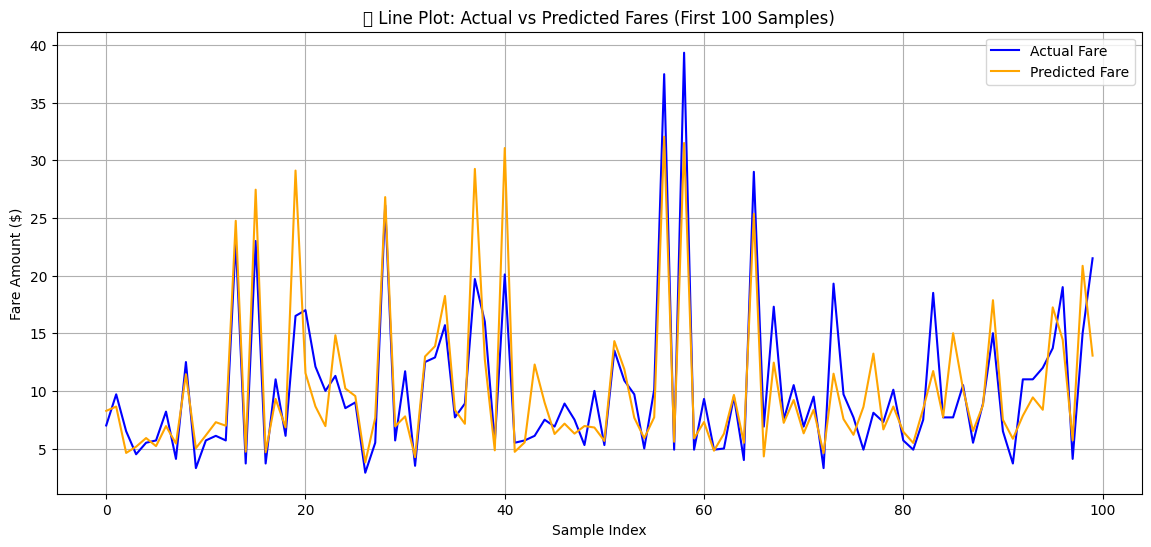

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import StackingRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")
df.rename(columns={'fare_amount': 'fare'}, inplace=True)
df.dropna(inplace=True)

# Remove invalid values
df = df[(df['pickup_longitude'] != 0) & (df['dropoff_longitude'] != 0)]
df = df[(df['fare'] > 0) & (df['passenger_count'] > 0)]

# Datetime processing
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear

# Haversine Distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                           df['dropoff_longitude'], df['dropoff_latitude'])

# Remove outliers
df = df[(df['distance'] > 0) & (df['distance'] < 100) & (df['fare'] < 200)]

# Feature 1: Estimated duration
df['estimated_duration'] = (df['distance'] / 18) * 60  # assuming avg speed 18 km/h

# Feature 2: Surge pricing simulation
def surge_multiplier(hour):
    if 7 <= hour <= 9 or 17 <= hour <= 20:
        return 1.5
    elif 22 <= hour or hour <= 5:
        return 1.3
    else:
        return 1.0

df['surge'] = df['hour'].apply(surge_multiplier)

# Feature 3: Pickup Zone Clustering
coords = df[['pickup_latitude', 'pickup_longitude']]
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df['pickup_zone'] = kmeans.fit_predict(coords)

# Log-transform target
df['log_fare'] = np.log1p(df['fare'])

# Feature selection
features = ['distance', 'passenger_count', 'hour', 'day', 'month', 'year', 'day_of_year',
            'estimated_duration', 'surge', 'pickup_zone']

X = df[features]
y = df['log_fare']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# LightGBM Grid Search
lgbm = lgb.LGBMRegressor(objective='regression', random_state=42)

param_grid = {
    'n_estimators': [500],
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2],
    'gamma': [0, 1]
}

grid_search_lgbm = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1, scoring='r2')
grid_search_lgbm.fit(X_train, y_train)
best_lgbm = grid_search_lgbm.best_estimator_

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=[
        ('lgbm', best_lgbm),
        ('xgb', XGBRegressor(n_estimators=300, random_state=42)),
    ],
    final_estimator=XGBRegressor(n_estimators=200, random_state=42),
    passthrough=True,
    n_jobs=-1
)

# Fit stacking model
stacking_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = np.expm1(stacking_model.predict(X_test))
y_actual = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"\n✅ Best LGBM Parameters: {grid_search_lgbm.best_params_}")
print(f"\n🎯 Final Model Performance - RMSE: {rmse:.4f}, R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(y_actual.values[:100], label='Actual Fare', color='blue')
plt.plot(y_pred[:100], label='Predicted Fare', color='orange')
plt.title("🔍 Line Plot: Actual vs Predicted Fares (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Fare Amount ($)")
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 7
[LightGBM] [Info] Start training from score 2.309427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

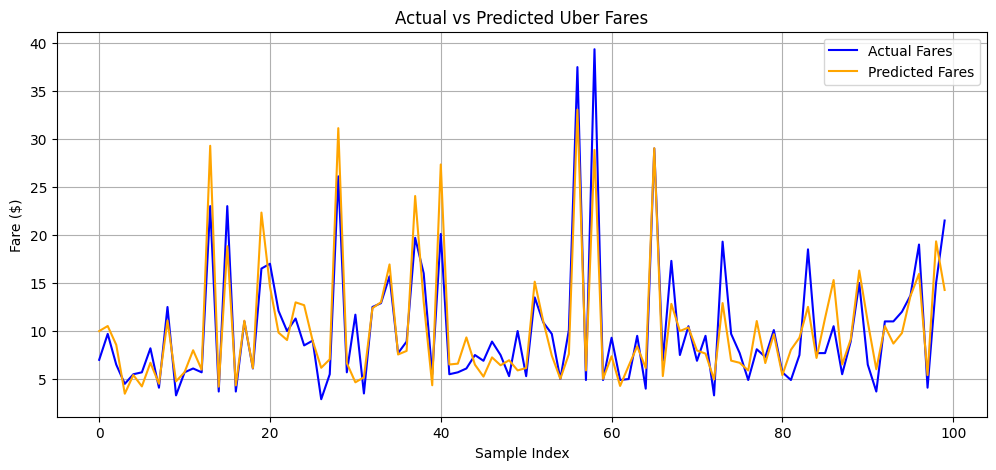

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")

# Drop nulls
df.dropna(inplace=True)

# Clean up fare and passengers
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 200)]
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

# Convert pickup datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

# Time features
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear

# Distance feature using haversine
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Earth radius in km

df['distance'] = haversine(
    df['pickup_longitude'], df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

# Filter invalid distances
df = df[(df['distance'] > 0) & (df['distance'] < 100)]

# Log transform the target
df['log_fare'] = np.log1p(df['fare_amount'])

# Features
features = ['distance', 'passenger_count', 'hour', 'day', 'month', 'year', 'day_of_year']
X = df[features]
y = df['log_fare']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model
model = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred_log = model.predict(X_test)

# Inverse log1p
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"✅ Final LightGBM Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Plotting actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(y_actual[:100].values, label='Actual Fares', color='blue')
plt.plot(y_pred[:100], label='Predicted Fares', color='orange')
plt.title("Actual vs Predicted Uber Fares")
plt.xlabel("Sample Index")
plt.ylabel("Fare ($)")
plt.legend()
plt.grid(True)
plt.show()

Fitting 3 folds for each of 384 candidates, totalling 1152 fits
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 7
[LightGBM] [Info] Start training from score 2.309427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

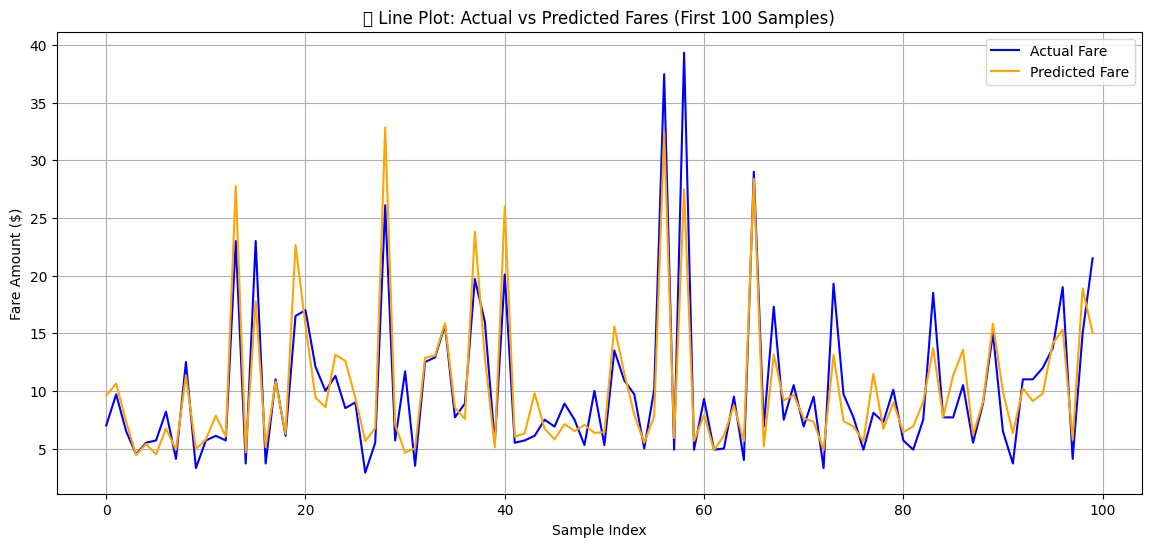

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Uber Fare Prediction/Uber Ride Price Data  - Sheet1.csv")

# Rename columns for ease
df.rename(columns={'fare_amount': 'fare'}, inplace=True)

# Data Preprocessing
df.dropna(inplace=True)

# Remove invalid rows
df = df[(df['pickup_longitude'] != 0) & (df['dropoff_longitude'] != 0)]
df = df[(df['fare'] > 0) & (df['passenger_count'] > 0)]

# Convert datetime to datetime object and add datetime features
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear  # Added this feature

# Haversine Distance Calculation
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['pickup_longitude'], df['pickup_latitude'],
                           df['dropoff_longitude'], df['dropoff_latitude'])

# Remove outliers
df = df[(df['distance'] > 0) & (df['distance'] < 100) & (df['fare'] < 200)]

# Log-transform target variable to reduce skewness
df['log_fare'] = np.log1p(df['fare'])

# Features and target variable
features = ['distance', 'passenger_count', 'hour', 'day', 'month', 'year', 'day_of_year']
X = df[features]
y = df['log_fare']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model - LightGBM with GridSearchCV for hyperparameter tuning
lgbm = lgb.LGBMRegressor(objective='regression', random_state=42)

param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2],
    'gamma': [0, 1]
}

grid_search_lgbm = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1, scoring='r2')
grid_search_lgbm.fit(X_train, y_train)

# Best model after grid search
best_lgbm = grid_search_lgbm.best_estimator_

# Prediction on test data
y_pred_log = best_lgbm.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse log transformation

y_actual = np.expm1(y_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"\n✅ Best LGBM Parameters: {grid_search_lgbm.best_params_}")
print(f"\n🎯 Final Model Performance - RMSE: {rmse:.4f}, R² Score: {r2:.4f} ({r2*100:.2f}%)")

# Visualization of predictions vs actual values
plt.figure(figsize=(14, 6))
plt.plot(y_actual.values[:100], label='Actual Fare', color='blue')
plt.plot(y_pred[:100], label='Predicted Fare', color='orange')
plt.title("🔍 Line Plot: Actual vs Predicted Fares (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Fare Amount ($)")
plt.legend()
plt.grid(True)
plt.show()